# Task 6: Detect road lane lines

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
names = ['images/solidWhiteRight.jpg', 'images/solidYellowCurve.jpg', 'images/whiteCarLaneSwitch.jpg']
imgs = [cv2.cvtColor(cv2.imread(n), cv2.COLOR_BGR2RGB) for n in names]
imgs[0].shape

(540, 960, 3)

In [3]:
def lane_lines(image):
    h, w = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    roi = np.zeros_like(edges)
    poly = np.int32([[(int(0.08 * w), h), (int(0.45 * w), int(0.6 * h)), (int(0.55 * w), int(0.6 * h)), (int(0.95 * w), h)]])
    cv2.fillPoly(roi, poly, 255)
    masked = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(masked, 1, np.pi / 180, 30, minLineLength=40, maxLineGap=100)
    left, right = [], []
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        if x1 == x2:
            continue
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        if abs(slope) < 0.4:
            continue
        (left if slope < 0 else right).append((slope, intercept))

    out = image.copy()
    y_top = int(0.62 * h)
    for side in (left, right):
        if side:
            slope, intercept = np.mean(side, axis=0)
            x_bottom = int((h - intercept) / slope)
            x_top = int((y_top - intercept) / slope)
            cv2.line(out, (x_bottom, h), (x_top, y_top), (255, 0, 0), 8)
    return masked, out, len(lines), len(left), len(right)

In [4]:
results = []
for name, im in zip(names, imgs):
    masked, out, total, nl, nr = lane_lines(im)
    print(name, '- segments:', total, 'left:', nl, 'right:', nr)
    results.append((masked, out))

images/solidWhiteRight.jpg - segments: 9 left: 4 right: 5
images/solidYellowCurve.jpg - segments: 10 left: 5 right: 5
images/whiteCarLaneSwitch.jpg - segments: 14 left: 7 right: 7


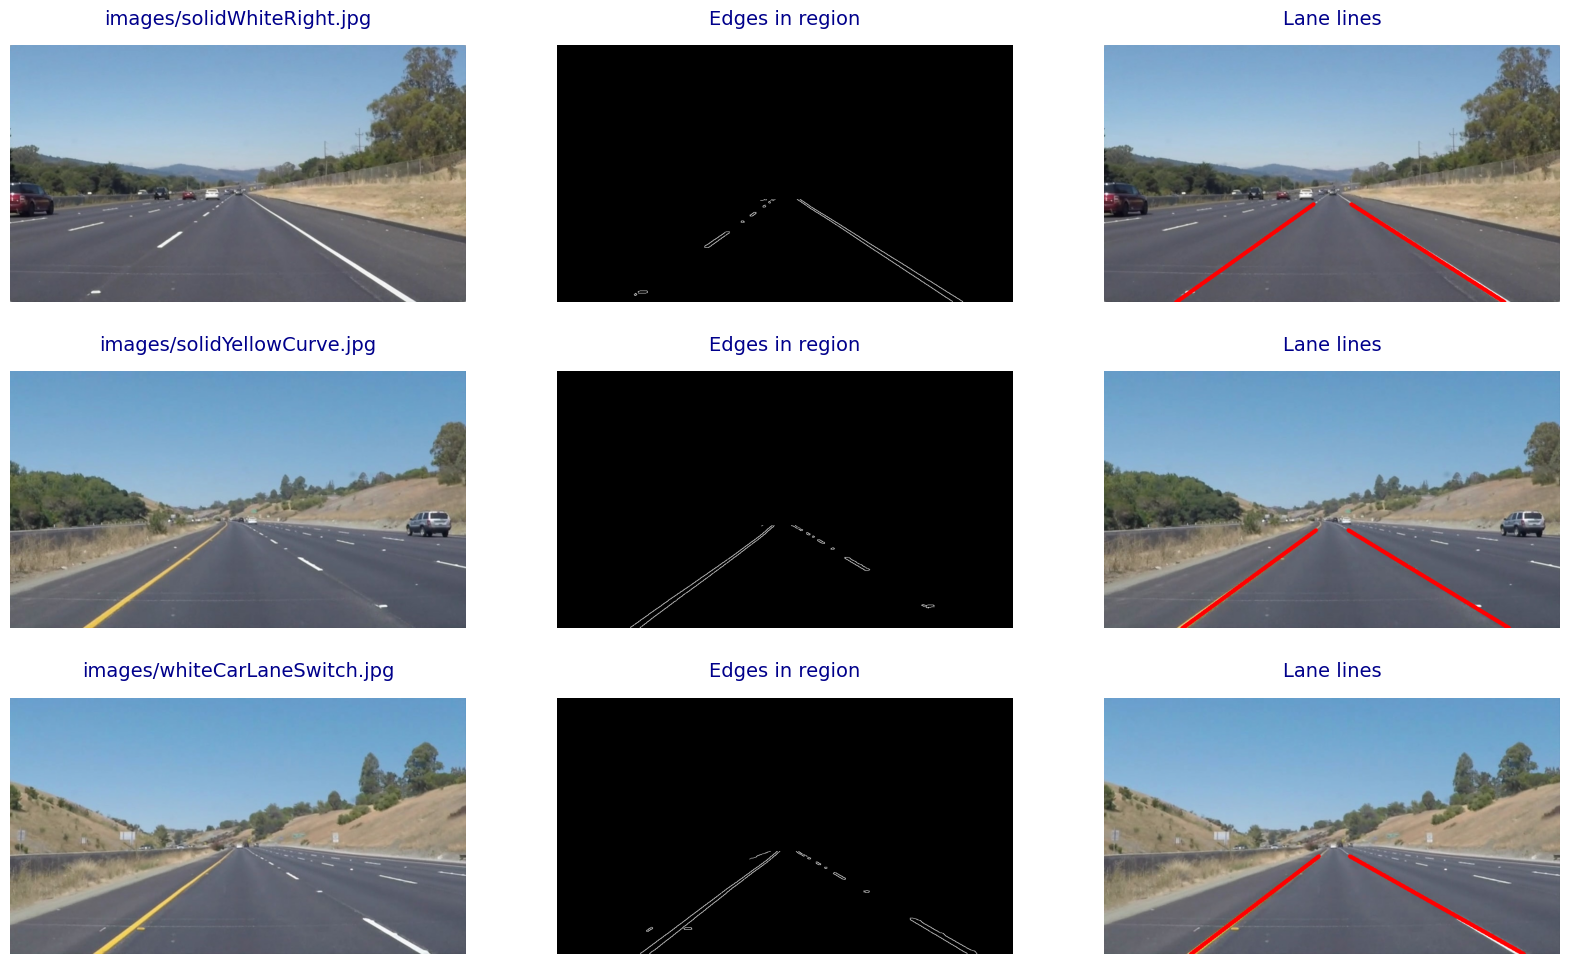

In [5]:
panels = []
for name, im, (masked, out) in zip(names, imgs, results):
    panels += [(name, im), ('Edges in region', masked), ('Lane lines', out)]

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()